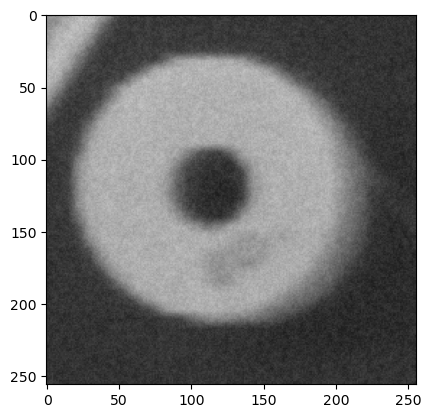

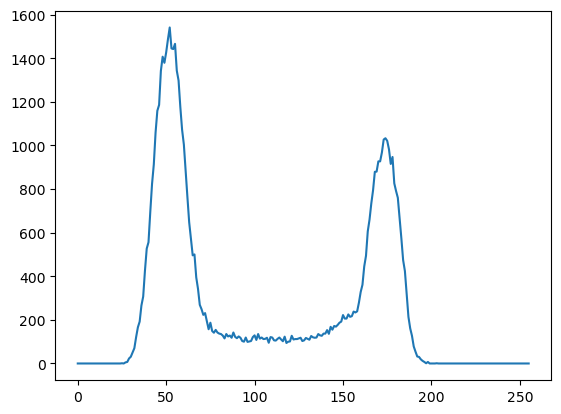

In [28]:
import cv2
import matplotlib.pyplot as plt

rondelle = cv2.imread('RONDELLE.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(rondelle, cmap='gray', vmin=0, vmax=255)
plt.show()
histO = cv2.calcHist([rondelle],[0],None,[256],[0,256])
plt.plot(histO)
plt.show()


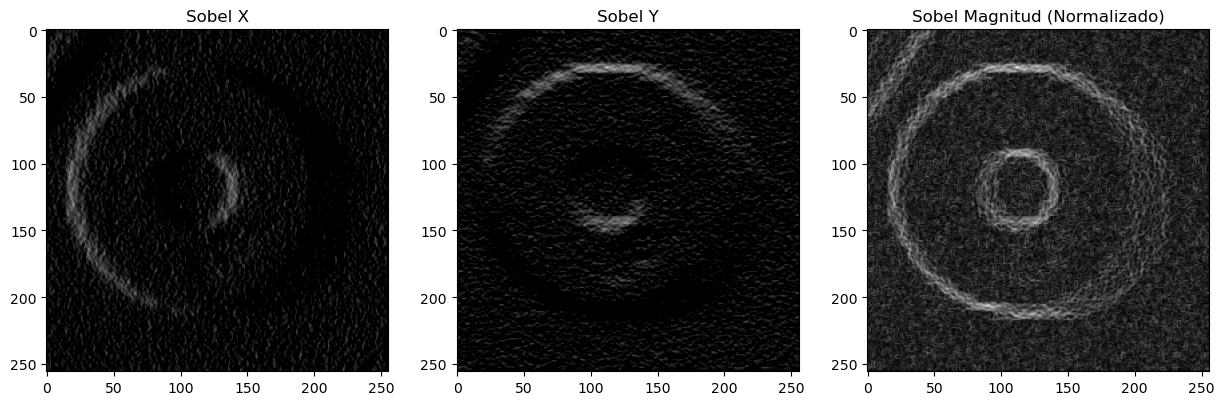

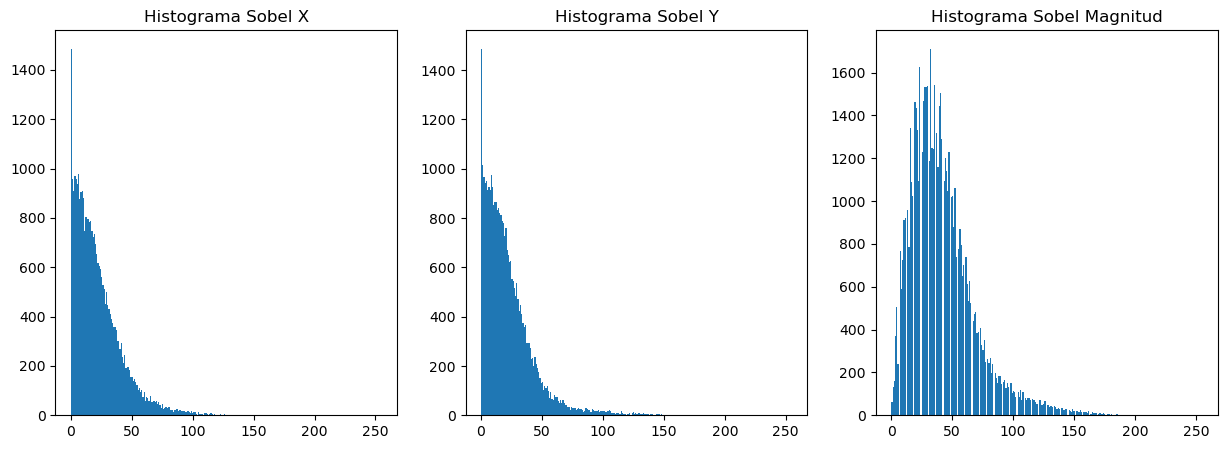

In [29]:
import numpy as np
from skimage import exposure

sobel_x = cv2.Sobel(rondelle, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(rondelle, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.hypot(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)
sobel_eq = exposure.rescale_intensity(sobel, in_range=(sobel.min(), sobel.max()))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(sobel_x, cmap='gray', vmin=0, vmax=255)
plt.title("Sobel X")
plt.subplot(1, 3, 2)
plt.imshow(sobel_y, cmap='gray', vmin=0, vmax=255)
plt.title("Sobel Y")
plt.subplot(1, 3, 3)
plt.imshow(sobel_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Sobel Magnitud (Normalizado)")
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(sobel_x.ravel(), bins=256, range=[0, 255])
plt.title("Histograma Sobel X")
plt.subplot(1, 3, 2)
plt.hist(sobel_y.ravel(), bins=256, range=[0, 255])
plt.title("Histograma Sobel Y")
plt.subplot(1, 3, 3)
plt.hist(sobel_eq.ravel(), bins=256, range=[0, 255])
plt.title("Histograma Sobel Magnitud")
plt.show()


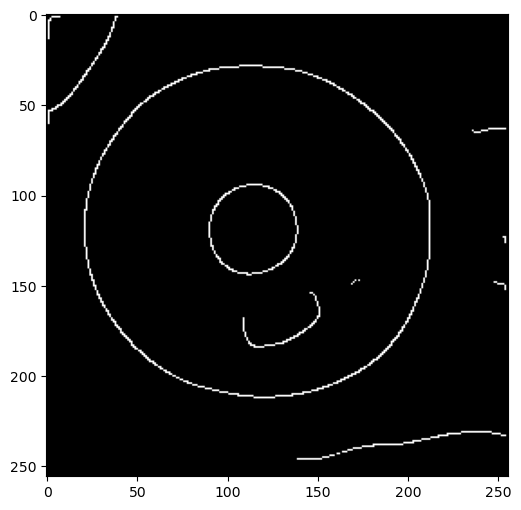

c:\Users\Usuario\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:6862: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


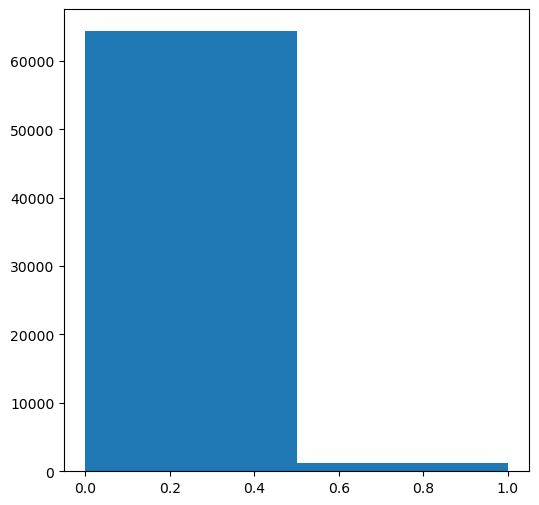

In [30]:
from skimage import io
from skimage.feature import canny

cannyP3 = canny(rondelle, sigma=10, low_threshold=0, high_threshold=1)
plt.figure(figsize=(6, 6))
plt.imshow(cannyP3, cmap='gray')
plt.show()
plt.figure(figsize=(6, 6))
plt.hist(cannyP3.ravel(), bins=2, range=[0, 1])
plt.show()


### Descripción:

La imagen resultante muestra los bordes principales de la estructura circular de la imagen original, con contornos delgados y bien definidos en un fondo negro. Debido a la alta desviación estándar (sigma = 10), la imagen fue suavizada antes de la detección, reduciendo el ruido y eliminando detalles menores. La umbralización estricta (umbral inferior = 0 y superior = 1) permitió conservar solo los contornos más fuertes, perdiendo algunos detalles.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4908\913888297.py:6: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_values, bin_edges = np.histogram(cannyP4.ravel(), bins=2, range=[0, 1])


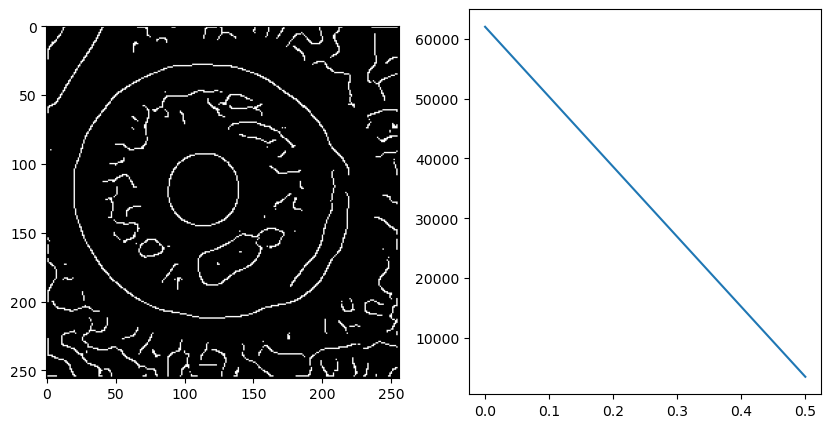

In [31]:
cannyP4 = canny(rondelle, sigma=5, low_threshold=0, high_threshold=1)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cannyP4, cmap='gray')

hist_values, bin_edges = np.histogram(cannyP4.ravel(), bins=2, range=[0, 1])
plt.subplot(1, 2, 2)
plt.plot(bin_edges[:-1], hist_values)
plt.show()


### Explicación:

Al reducir la desviación estándar sigma de 10 5 en el operador de Canny, la imagen no se sualiza tanto antes de la detección de bordes, lo que permite resaltar más detalles. Como resultado, se detectan más bordes, incluyendo algunos que antes eran eliminados por el suavizado intenso como esa especie de estrías que se ven en el interior y exterior del círculo. Esto hace que los contornos esten más definidos, pero también aumenta la sensibilidad a pequeñas variaciones en la imagen, lo que puede generar ruido no deseado.

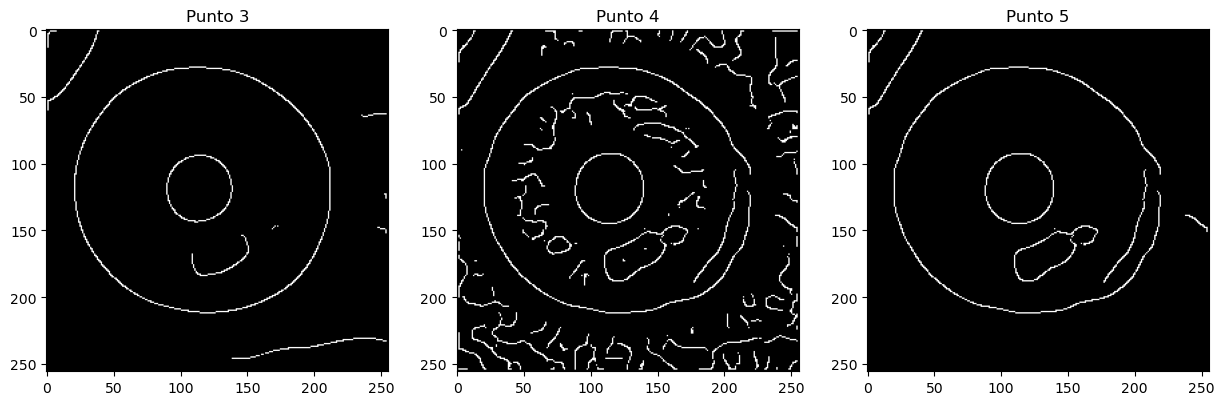

In [32]:
cannyP5 = canny(rondelle, sigma=5, low_threshold=0, high_threshold=5)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cannyP3, cmap='gray')
plt.title("Punto 3")
plt.subplot(1, 3, 2)
plt.imshow(cannyP4, cmap='gray')
plt.title("Punto 4")
plt.subplot(1, 3, 3)
plt.imshow(cannyP5, cmap='gray')
plt.title("Punto 5")
plt.show()


### Comparación:

Al comparar los tres puntos, se observa que un valor alto de sigma (Punto 3) suaviza la imagen mucho, filtrando los detalles finos y resaltando solo los bordes principales, lo que reduce el ruido pero también elimina mucha información. Al disminuir sigma (Punto 4), se detectan más detalles y contornos finos, pero también aumenta el ruido en la imagen, haciendo que se vean más líneas y texturas internas. Finalmente, al mantener sigma en 5 pero aumentar el umbral superior (Punto 5), se logra filtrar los bordes menos fuertes y conservar solo los más pronunciados, lo que reduce el ruido y mejora la claridad de los contornos principales.